[*********************100%***********************]  1 of 1 completed


Success! Data saved to: data/AAPL_2015_2024.csv
Data Shape: (2264, 5)


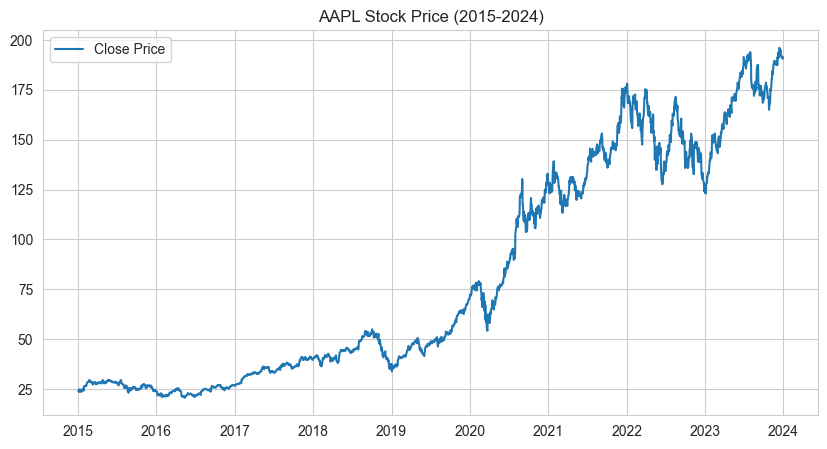

In [1]:
# Phase 1: Data Acquisition
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_style('whitegrid')
%matplotlib inline

# 1. Define the ticker and date range
ticker_symbol = 'AAPL' 
start_date = '2015-01-01'
end_date = '2024-01-01'

# 2. Fetch Data
print(f"Downloading data for {ticker_symbol}...")
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# 3. Save to 'data' folder
if not os.path.exists('data'):
    os.makedirs('data')

file_name = f"data/{ticker_symbol}_{start_date[:4]}_{end_date[:4]}.csv"
df.to_csv(file_name)

# 4. Show success and plot
print(f"Success! Data saved to: {file_name}")
print(f"Data Shape: {df.shape}")

plt.figure(figsize=(10, 5))
plt.plot(df['Close'], label='Close Price')
plt.title(f'{ticker_symbol} Stock Price (2015-2024)')
plt.legend()
plt.show()

In [2]:
# Phase 2: Feature Engineering with Multiple Targets

# 1. Create Input Features (The "Clues")
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['Daily_Return'] = df['Close'].pct_change()

# 2. Create MULTIPLE Target Variables (The "Answers" for tomorrow)
# Shifting by -1 pulls tomorrow's price onto today's row
df['Target_Close'] = df['Close'].shift(-1)
df['Target_High'] = df['High'].shift(-1)
df['Target_Low'] = df['Low'].shift(-1)

# 3. Clean the dataset (Crucial: Removes rows with NaNs)
df = df.dropna()

print(f"Phase 2 Complete. Data shape after engineering and cleaning: {df.shape}")

Phase 2 Complete. Data shape after engineering and cleaning: (2214, 11)


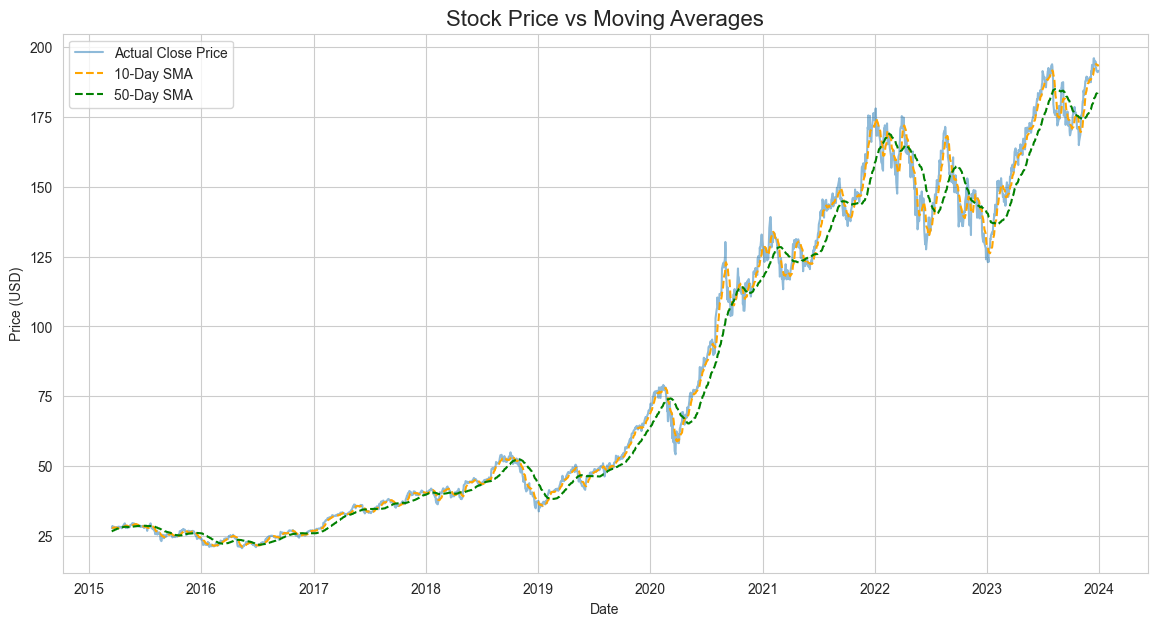

In [3]:
# Phase 3: Exploratory Data Analysis (EDA) - Trends

plt.figure(figsize=(14, 7))

# Plot the Actual Closing Price
plt.plot(df.index, df['Close'], label='Actual Close Price', alpha=0.5)

# Plot the 10-Day SMA (Fast Trend)
plt.plot(df.index, df['SMA_10'], label='10-Day SMA', color='orange', linestyle='--')

# Plot the 50-Day SMA (Slow Trend)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='green', linestyle='--')

plt.title('Stock Price vs Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

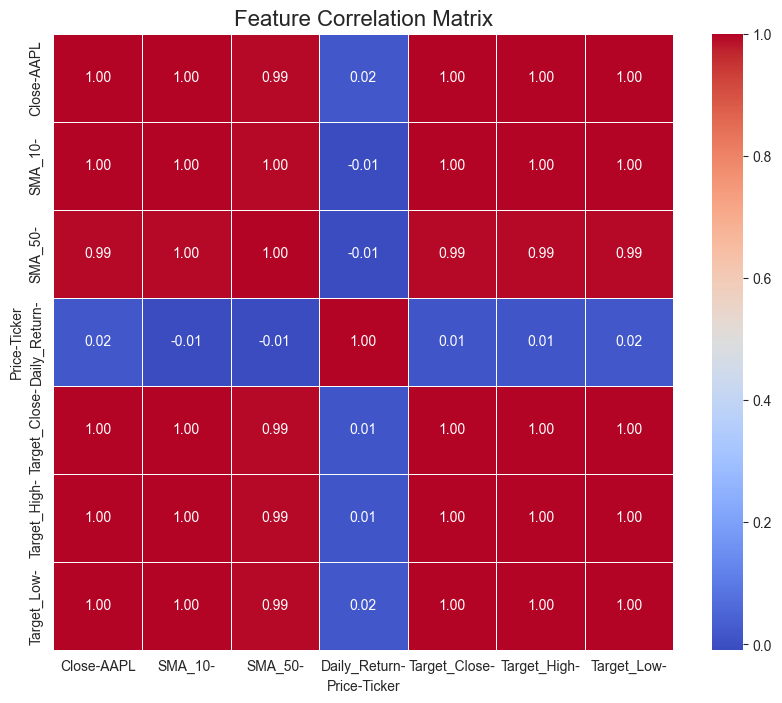

In [4]:
# Phase 3: EDA - Correlation Heatmap

# Select only numerical columns for correlation
cols_to_check = ['Close', 'SMA_10', 'SMA_50', 'Daily_Return', 'Target_Close', 'Target_High', 'Target_Low']
corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

In [5]:
# Phase 4: Train Multiple Ridge Models

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

# 1. Define Features (Inputs)
features = ['SMA_10', 'SMA_50', 'Daily_Return']
X = df[features]

# Define the three Targets (Outputs)
y_close = df['Target_Close']
y_high = df['Target_High']
y_low = df['Target_Low']

# 2. Time-Series Split (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)

# Split Inputs
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# Split the three Targets sequentially
y_close_train, y_close_test = y_close.iloc[:split_idx], y_close.iloc[split_idx:]
y_high_train, y_high_test = y_high.iloc[:split_idx], y_high.iloc[split_idx:]
y_low_train, y_low_test = y_low.iloc[:split_idx], y_low.iloc[split_idx:]

# 3. Scale the Features (Mandatory for Regularisation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize Three Separate Ridge Models
model_close = Ridge(alpha=1.0)
model_high = Ridge(alpha=1.0)
model_low = Ridge(alpha=1.0)

# 5. Train All Three Models
print("Training models...")
model_close.fit(X_train_scaled, y_close_train)
model_high.fit(X_train_scaled, y_high_train)
model_low.fit(X_train_scaled, y_low_train)

# 6. Evaluate All Three (Using MAE to see average dollar error)
mae_close = mean_absolute_error(y_close_test, model_close.predict(X_test_scaled))
mae_high = mean_absolute_error(y_high_test, model_high.predict(X_test_scaled))
mae_low = mean_absolute_error(y_low_test, model_low.predict(X_test_scaled))

print("-" * 45)
print(f"{'Target Prediction':<20} | {'Mean Absolute Error':<20}")
print("-" * 45)
print(f"{'Next Day Close':<20} | ${mae_close:<19.2f}")
print(f"{'Next Day High':<20} | ${mae_high:<19.2f}")
print(f"{'Next Day Low':<20} | ${mae_low:<19.2f}")

Training models...
---------------------------------------------
Target Prediction    | Mean Absolute Error 
---------------------------------------------
Next Day Close       | $3.94               
Next Day High        | $3.54               
Next Day Low         | $3.75               


In [6]:
# Phase 5: Export Models for Web Application
import joblib
import os

# 1. Create a directory for the models
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Save the Scaler (So the web app scales new user input identically)
joblib.dump(scaler, 'models/feature_scaler.pkl')

# 3. Save all three trained models
joblib.dump(model_close, 'models/ridge_close.pkl')
joblib.dump(model_high, 'models/ridge_high.pkl')
joblib.dump(model_low, 'models/ridge_low.pkl')

print("Phase 5 Complete: Scaler and 3 Ridge Models successfully saved to the 'models' folder!")

Phase 5 Complete: Scaler and 3 Ridge Models successfully saved to the 'models' folder!
